<a href="https://colab.research.google.com/github/lidia-notebook/Student-GPA-Prediction/blob/main/StudentPerformance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STUDENT PERFORMANCE PREDICTION**

### **Objective**
The goal of this project is to **predict student performance** based on various academic, demographic, and behavioral factors.


### **Background**
Student performance is influenced dby ultiple dimensions, including:
* Study habits and academic engagement
* Attandence and participation
* Socio-demographic background
* External support systems.
Understanding these factors is important for identifying patterns that contribute to academic success or underperformence.

### **Business Problem**
Educational institutions often face challenges such as:
* Difficulty identifying students at risk of poor performance early.
* Lack of data-driven decision-making for intervantions
* Inefficient allocation of academic support resources.

### **Analytical Approach**
To address this problem, tis project will:
1. Perform **EDA** to udnerstand data patterns
2. Aooly **feature engineering and preprocessing pipelines**
3. Build a **regression model using ensamble learning methods**
4. Optimize the model using **Optuna hyperparameter tuning**
5. Evaluate model performance using appropriate regression metrics


### **Metrics**
This model will be evaluated using:
* **MAE (Mean Absolute Error)** → measures average prediction error
* **RMSE (Root Mean Squared Error)** → penalizes larger erros
* **R² Score** → indicates how well the model explains variance

## 2. **Data Understanding**

Here we want to udnerstand the data from its structure, quality, and characteristics of the dataset before performing analysis and modeling.

before we are going to do that, let's install the libraries first

In [63]:
# Core data handling
!pip install pandas numpy -q

# Visualization
!pip install matplotlib seaborn -q

# Machine Learning
!pip install scikit-learn -q

# Hyperparameter tuning
!pip install optuna -q

# Model saving
!pip install joblib -q

# Google Drive download
!pip install gdown -q

# (Optional for later - Streamlit app)
!pip install streamlit -q

# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# hyperparameter tuning
import optuna

# saving model
import joblib

# download from gdrive
import gdown

# utilities
import json

In [2]:
# Load the dataset
!pip install gdown -q

import gdown

file_id = "1bbEd7bZKt69wS7trzQJNp8ARliRdMjqb"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "StudentPerformance.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1bbEd7bZKt69wS7trzQJNp8ARliRdMjqb
To: /content/StudentPerformance.csv
100%|██████████| 167k/167k [00:00<00:00, 4.56MB/s]


'StudentPerformance.csv'

In [3]:
df = pd.read_csv("StudentPerformance.csv")

# preview
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [4]:
# check shape
print("Shape:", df.shape)


Shape: (2392, 15)


In [5]:
# check data types & missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
# statistical summary
df.describe(include='all')

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


Now, let's data understanding

| Column Name        | Description |
|-------------------|------------|
| **StudentID**     | Unique identifier for each student |
| **Age**           | Age of the student |
| **Gender**        | Gender of the student |
| **StudyHours**    | Number of hours spent studying per day/week |
| **Attendance**    | Percentage of class attendance |
| **ParentalEducation**| Education level of parents |
| **FamilyIncome**  | Family income level |
| **SchoolType**    | Type of school (e.g., public/private) |
| **InternetAccess** | Whether the student has internet access (Yes/No) |
| **Extracurricular**| Participation in extracurricular activities |
| **SleepHours**     | Average number of hours slept per day |
| **PreviousScores** | Previous academic performance |
| **FinalScore**     | Final exam score (Target Variable) |

In [7]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

After that, we are going to check the **missing values** and **duplicates**

In [8]:
# check missing values
missing_values = df.isnull().sum()
print("Missing Values:\n")
display(missing_values)


Missing Values:



,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [9]:
# check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)


Number of Duplicate Rows: 0


From the results above, there are no missing values either duplicates. Which means **this data is clean**. That's why we move to the **2.1, Feature Target Identification**

### **2.1 Feature Target Identification**

In [10]:
target = 'GPA'

our main focus is GPA that's why we put it as target. Next, we are going to remove `Student`ID as it has no predictive meaning and will just give noise later on prediction.

In [11]:
df = df.drop(columns=['StudentID'])

### **2.2 Separate Features & Target**

In [12]:
X = df.drop(columns=[target])
y = df[target]

In simple, we are splitting the dataset into
* **Target (y)** , the **what** we want to predict, which in our case is **GPA**.
* **Features (X)** simple are the inputes used to make the predictions (`age, StudentTimeWeekly, Absences`, etc)

### **2.3 Identify Numerical &. Categorical Columns**

In [13]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']
Categorical Columns: []


It is important because later,
* Numerical.  are going to scale it
* Categorical. are going to enxoding it.
As ML **needs different treatment** for each type.

In [14]:
columns_config = {
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": target
}

with open("columns_config.json", "w") as f:
    json.dump(columns_config, f, indent=4)

print("columns_config.json saved")

columns_config.json saved


We save it just in case we are going make streamlit for this case.

## **3. EXPLORATORY DATA ANALYSIS (EDA)**

### **3.1 Univariate Analysis (Numerical)**

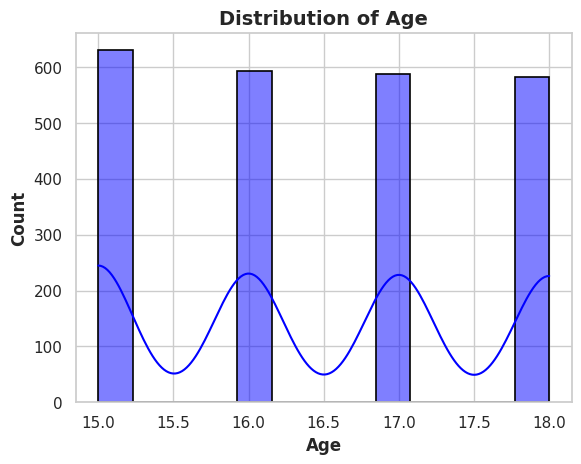

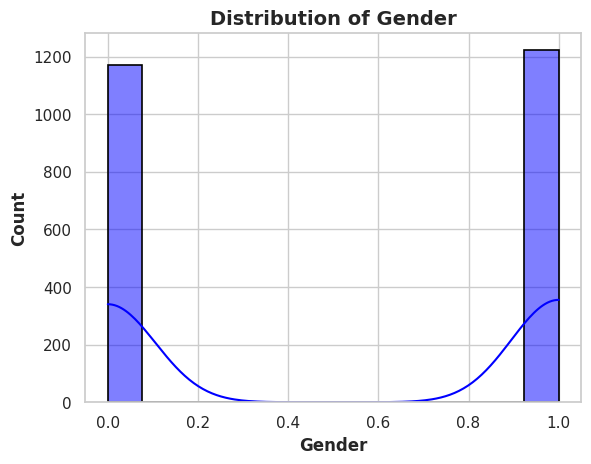

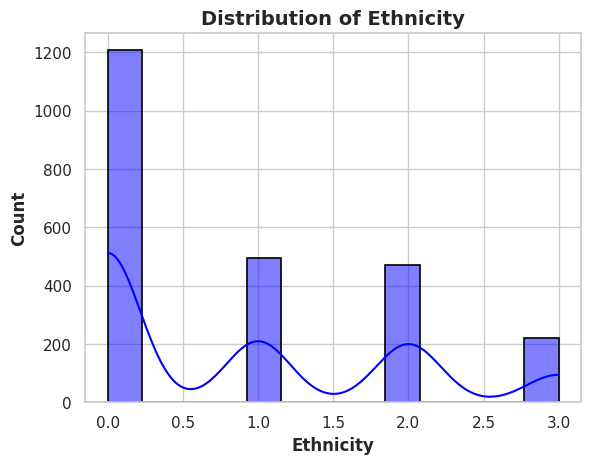

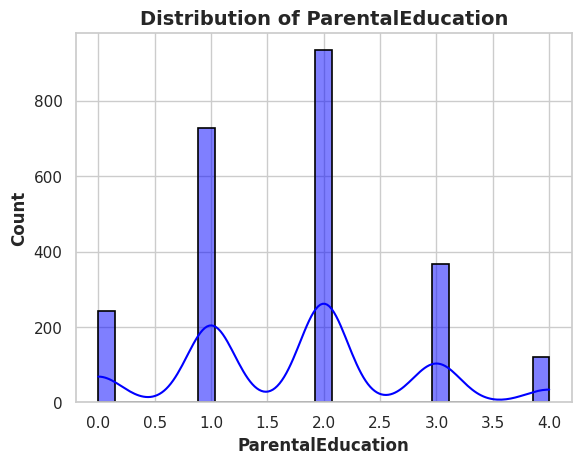

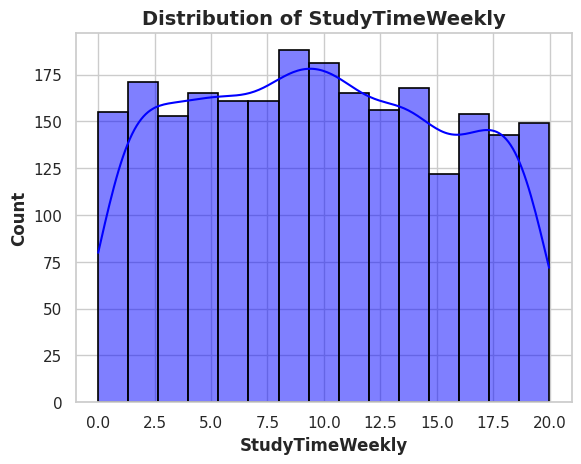

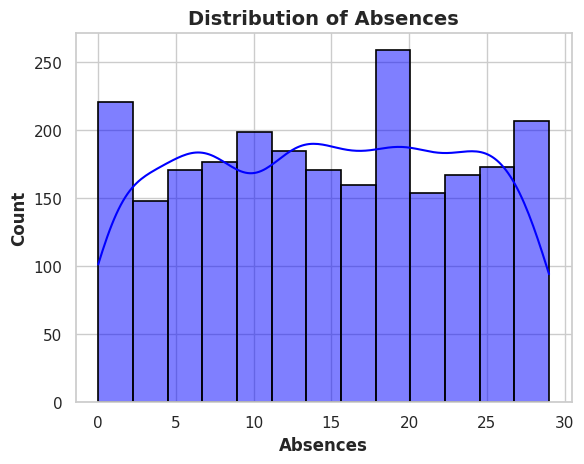

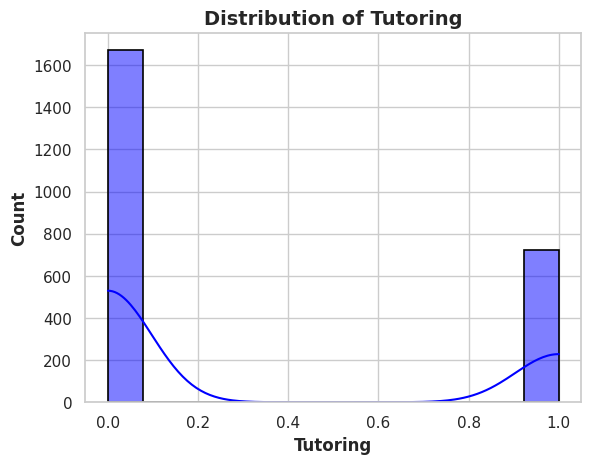

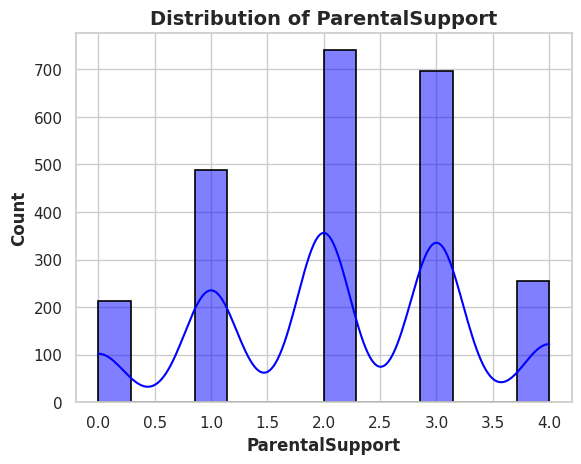

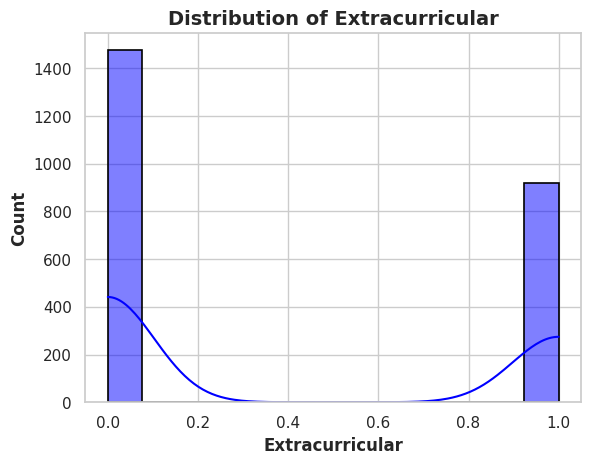

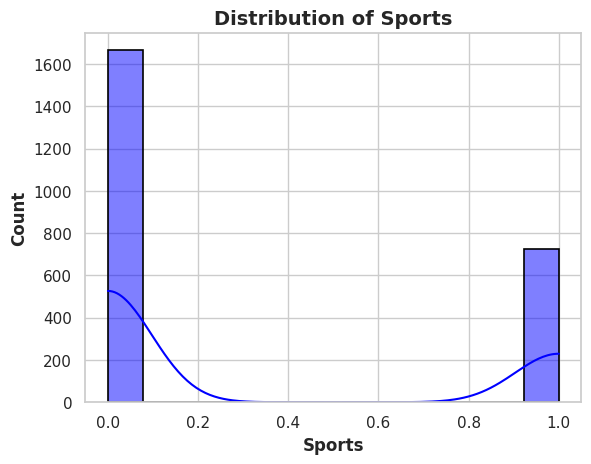

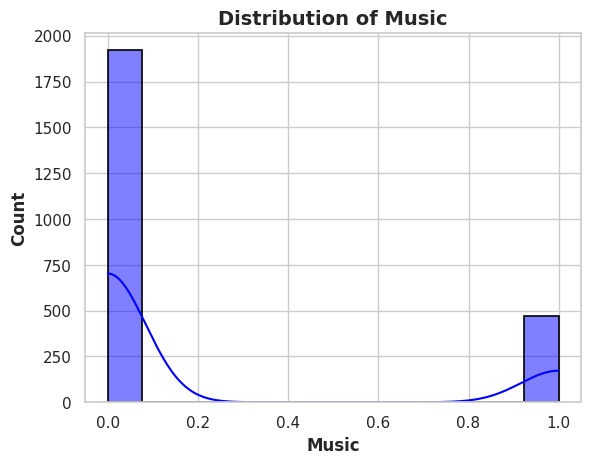

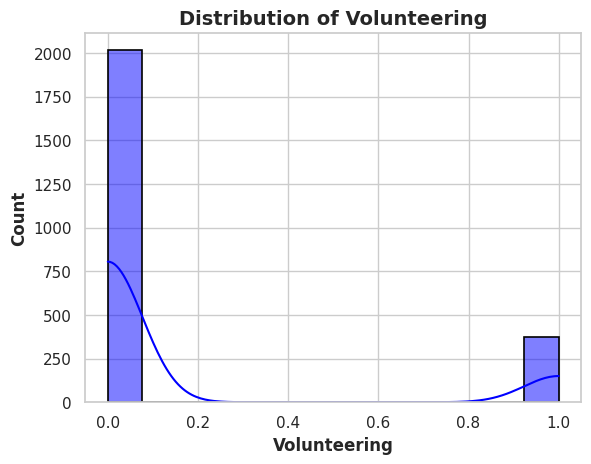

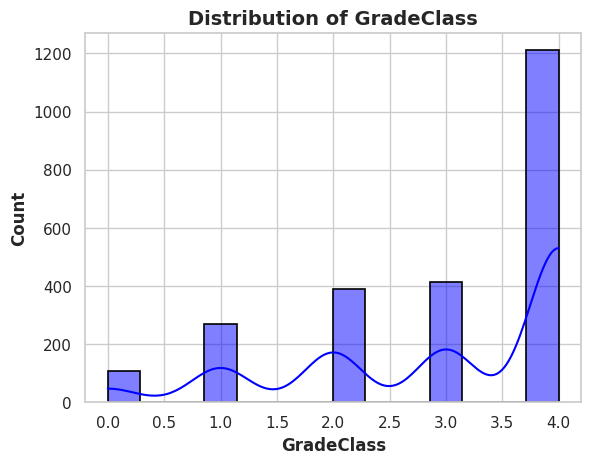

In [15]:
sns.set(style="whitegrid")

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, color="blue", edgecolor="black", linewidth=1.2)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel('Count', fontsize=12, fontweight='bold')


**Univariate Analysis Insights**

**Numerical Features**

- **`Age`**
  - Students are mostly between ages 15–18
  - Distribution is relatively balanced with no extreme outliers

- **`StudyTimeWeekly`**
  - Study time is fairly evenly distributed from low to high
  - Indicates diverse study habits among students

- **`Absences`**
  - Absences are spread across a wide range (0–30)
  - Suggests variability in student attendance behavior

**Categorical Features**

- **`Gender`**
  - Distribution is balanced between categories
  - No gender imbalance in dataset

- **`Ethnicity`**
  - One group dominates the dataset
  - Potential bias or imbalance across ethnic groups

- **`ParentalEducation`**
  - Most parents fall into mid-level education categories
  - Fewer observations at extreme levels

- **`Tutoring`**
  - Majority of students do not receive tutoring
  - Smaller portion receives additional academic support

- **`ParentalSupport`**
  - Most students receive moderate to high parental support
  - Very low support levels are less common

- **`Extracurricular, Sports, Music, Volunteering`**
  - Majority of students do not participate (skewed toward 0)
  - Participation is relatively low across activities

- **`GradeClass`**
  - Higher grade classes appear more frequently
  - Possible correlation with GPA (needs further validation)

### **3.2 Target Variable Distribution (GPA)**

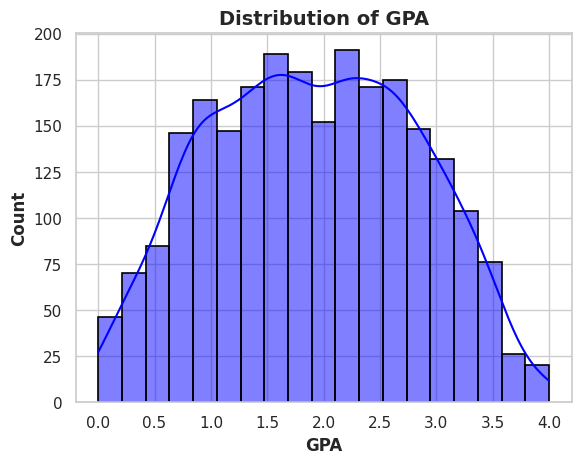

In [16]:
plt.figure()
sns.histplot(y, kde=True, color="blue", edgecolor="black", linewidth=1.2)

plt.title('Distribution of GPA', fontsize=14, fontweight='bold')
plt.xlabel('GPA', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

plt.show()

**Insights**

- GPA is distributed in a roughly normal (bell-shaped) pattern  
- Most students fall within the mid-range GPA (around 1.5 – 3.0)  
- Very low and very high GPAs are less frequent  

**From business lens,**
- The dataset is balanced, meaning the model can learn patterns effectively  
- No extreme skew → reduces risk of biased predictions  
- Model performance is likely to be stable across different student groups  

### **3.3 Feature vs `Target` (Numerical)**

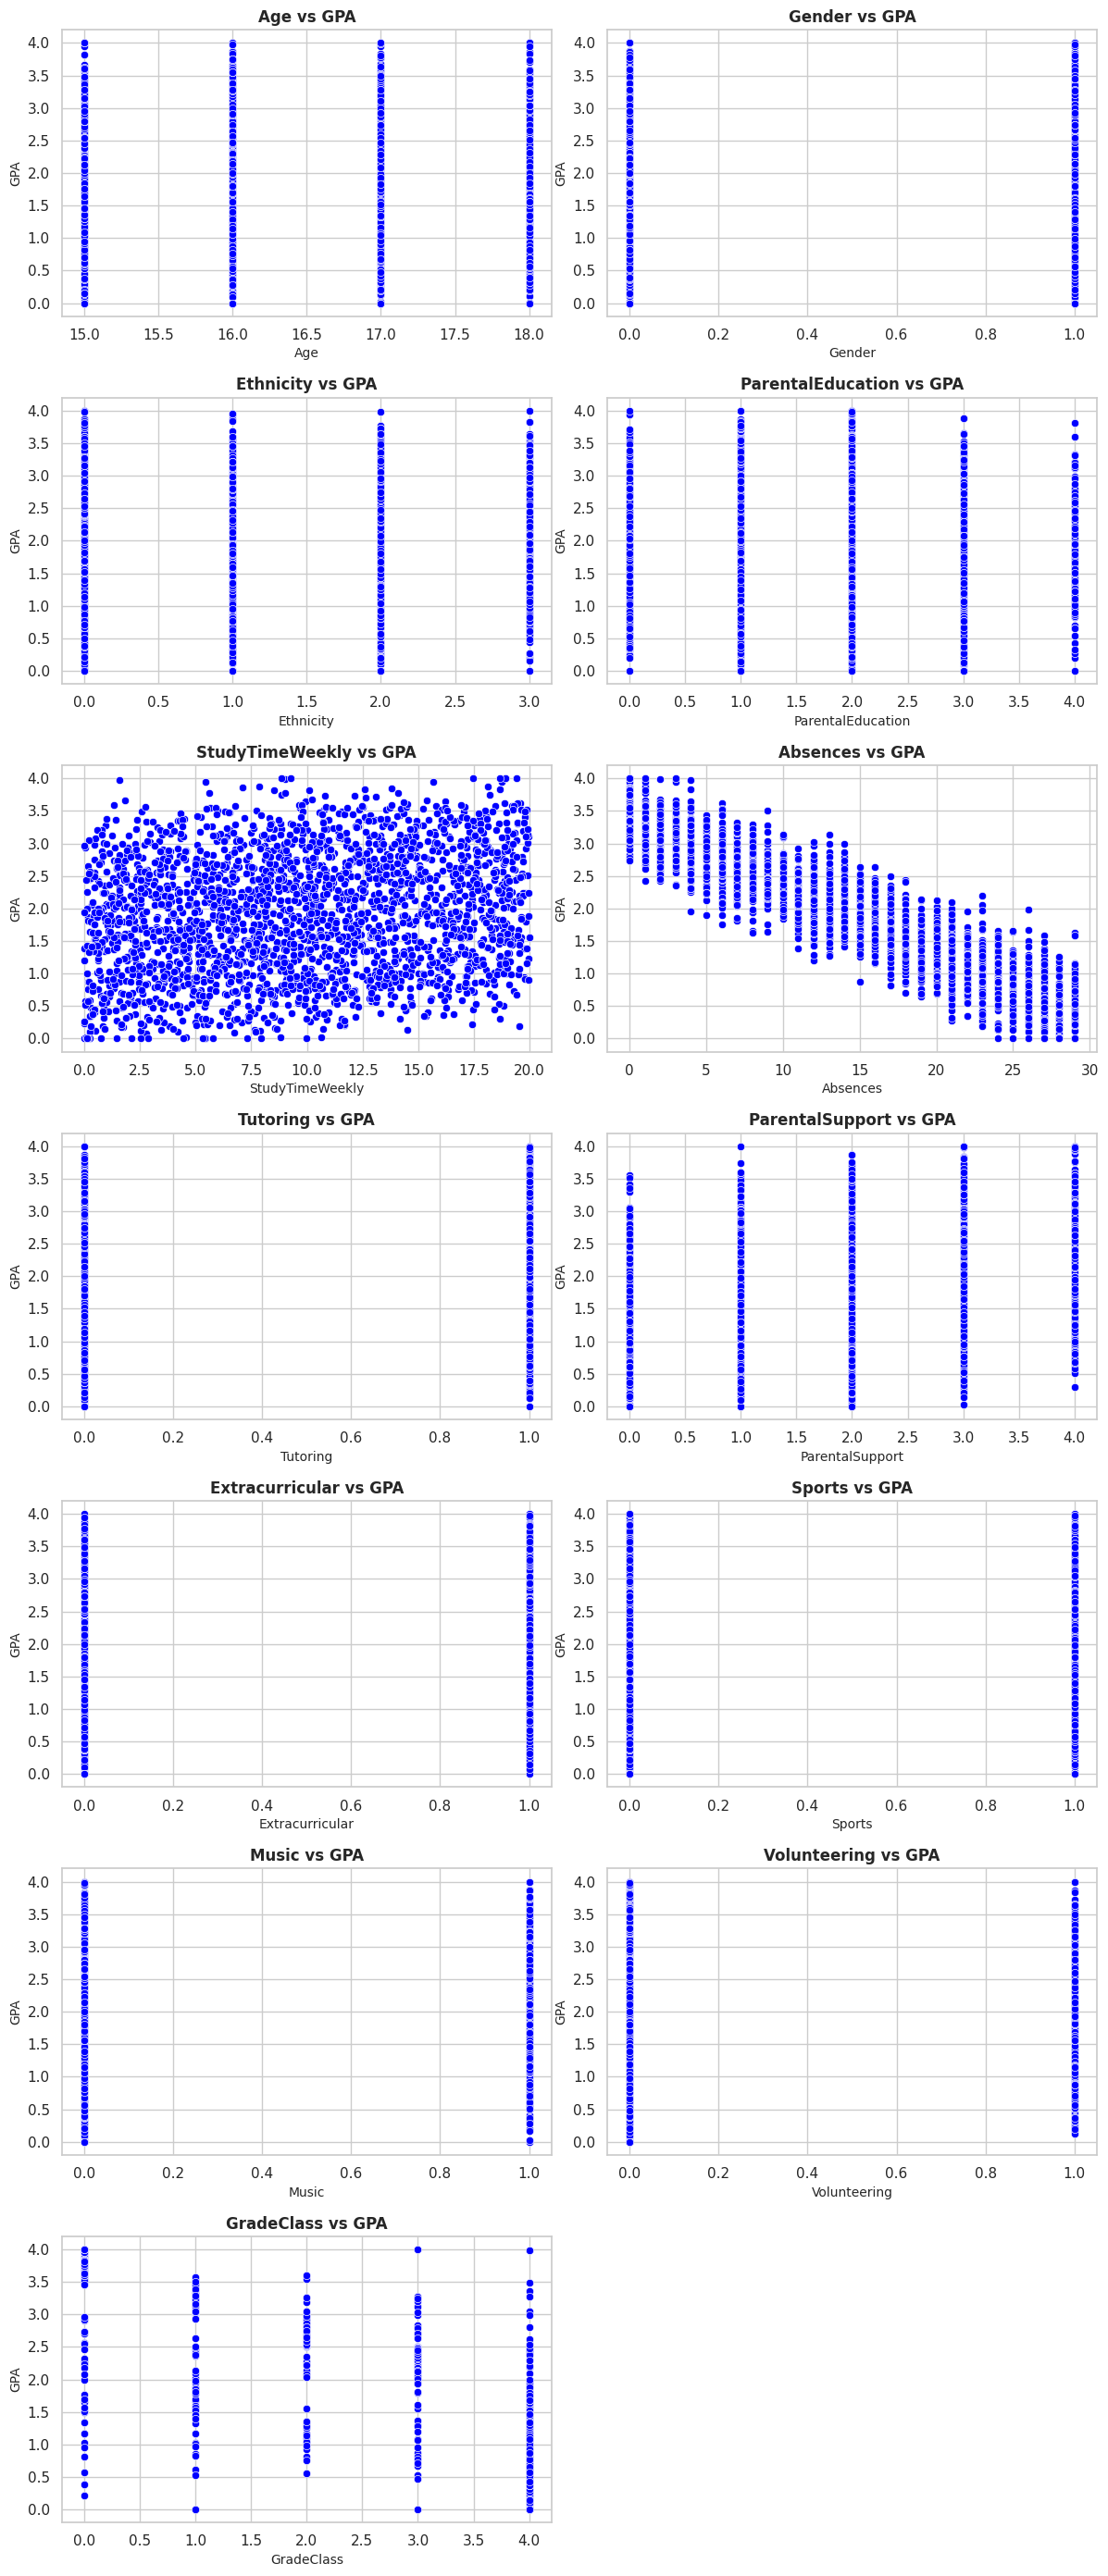

In [17]:
import math

cols_per_row = 2
rows = math.ceil(len(num_cols) / cols_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols_per_row, i+1)

    sns.scatterplot(x=df[col], y=y, color="blue")

    plt.title(f'{col} vs GPA', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('GPA', fontsize=10)

plt.tight_layout()
plt.show()

**Analysis Takeaways**

#### Strong Relationships

- **`Absences`**
  - Clear negative relationship with GPA
  - Higher absences → significantly lower GPA
  -  Business Insight: Attendance is a critical driver of student performance and should be a primary focus for intervention

- **`StudyTimeWeekly`**
  - Slight positive trend with GPA
  - More study time tends to improve performance, but not strongly
  -  Business Insight: Study time matters, but alone is not sufficient to guarantee high performance

#### Weak / No Clear Relationships

- **`Age`**
  - No clear pattern with GPA
  -  Business Insight: Age is not a key factor in academic performance

- **`Gender`**
  - GPA distribution is similar across categories
  -  Business Insight: No significant performance gap based on gender

- **`Ethnicity`**
  - No strong visible pattern with GPA
  - Business Insight: Ethnicity does not appear to directly influence performance in this dataset

#### Moderate / Potential Influence

- **`ParentalEducation`**
  - Slight variation in GPA across levels
  -  Business Insight: Family education background may have some influence, but not dominant

- **`ParentalSupport`**
  - Higher support levels show slightly higher GPA concentration
  - Business Insight: Support system contributes to better academic outcomes

- **`Tutoring`**
  - Students with tutoring show slightly higher GPA spread
  - Business Insight: Additional academic support may improve performance


#### Low Impact Features

- **`Extracurricular`, `Sports`, `Music`, `Volunteering`**
  - No clear separation in GPA
  -  Business Insight: These activities do not directly impact academic performance (based on this dataset)


#### Critical Observation

- **`GradeClass`**
  - Strong visible pattern with GPA
  - Likely derived from GPA itself
  - Business Insight: This is a potential data leakage feature and should be removed in modeling

### **3.4 Correlation Heatmap (Numerical only)**

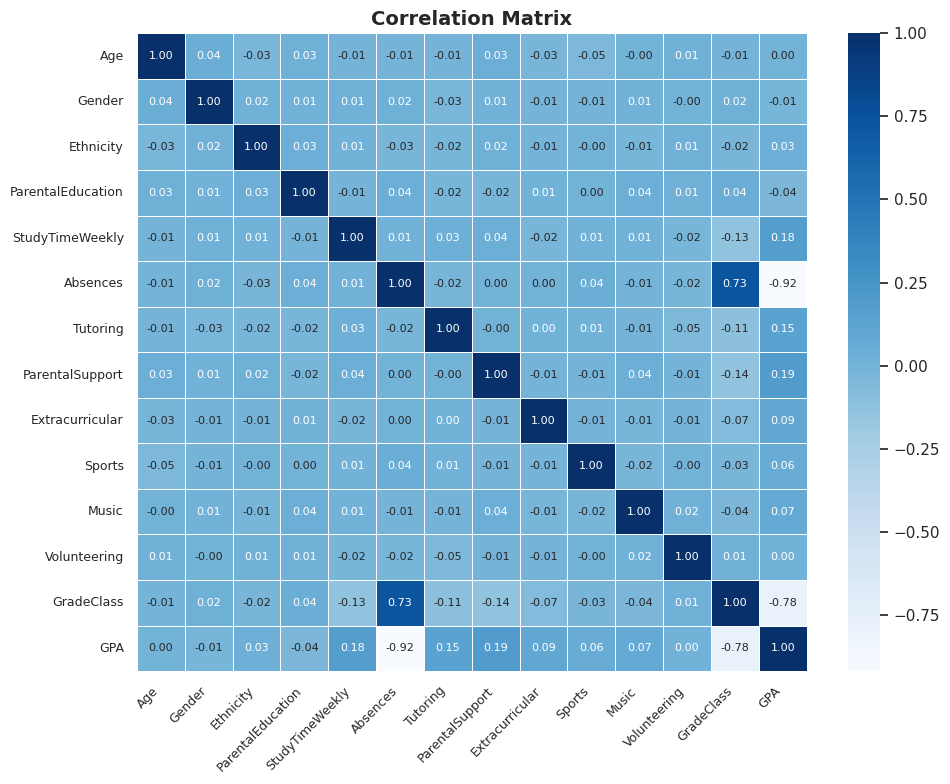

In [18]:
plt.figure(figsize=(10,8))

corr = df[num_cols + [target]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

| Feature             | Category               | Correlation with GPA | Insight                                                                 |
|---------------------|------------------------|----------------------|-------------------------------------------------------------------------|
| `Absences `           | Strong Relationship    | -0.92                | Very strong negative relationship; higher absences significantly reduce GPA |
| `GradeClass `         | Strong Relationship    | -0.78                | Likely derived from GPA; introduces data leakage risk                   |
| `ParentalSupport  `   | Moderate Relationship  | 0.19                 | Higher parental support slightly improves academic performance          |
| `StudyTimeWeekly `    | Moderate Relationship  | 0.18                 | Increased study time contributes to better GPA, but impact is limited   |
| `Tutoring `           | Moderate Relationship  | 0.15                 | Additional academic support has a positive but moderate effect          |
| `Extracurricular`     | Weak Relationship      | 0.09                 | Minimal direct impact on GPA                                            |
| `Sports `             | Weak Relationship      | 0.06                 | Very weak relationship with academic performance                        |
| `Music`               | Weak Relationship      | 0.07                 | Very weak relationship with GPA                                         |
| `Age`                 | No Significant Impact  | ~0.00                | No meaningful relationship with GPA                                     |
|` Gender `             | No Significant Impact  | ~0.00                | No meaningful relationship with GPA                                     |
| `Ethnicity`           | No Significant Impact  | ~0.00                | No meaningful relationship with GPA                                     |
| `ParentalEducation`   | No Significant Impact  | ~0.00                | No meaningful relationship with GPA                                     |

## **4. FEATURE ENGINEERING**

### **4.1 Split Data (Train & Test)**

In [19]:
X = df.drop(columns=['GPA', 'GradeClass'])
y = df['GPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **4.2 Modeling (Baseline model)**
In this step we are going to build a simple baseline model before tuning anything.

In [29]:
model = LinearRegression()

In [30]:
# train
model.fit(X_train, y_train)



LinearRegression()

In [31]:
# predict
y_pred = model.predict(X_test)

In [32]:
# evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [33]:
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.03866144149454255
R2 Score: 0.9532471681022928


From the result, it is still relatively high so there's might hidden leakage or a proxy variable.

In [34]:
X.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering'],
      dtype='object')

After we checked there's no obvious leakage feature anymore. The model achieved a very high R² (~0.95), which suggests either strong linear relationships or that the dataset may be synthetic or constructed. In real-world scenarios, such performance is uncommon, so further validation would be required.

### **4.3 Tree-Based Model**
We want to try to see if performance stays high

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
# model
rf = RandomForestRegressor(random_state=42)

In [38]:
# train
rf.fit(X_train, y_train)

# predict
y_pred_rf = rf.predict(X_test)

In [39]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RF MSE:", mse_rf)
print("RF R2:", r2_rf)

RF MSE: 0.06049515597539183
RF R2: 0.9268439109198162


From the result we can see **linear > Random Forest** which means a strong signal. A strong signal of relationship between features and GPA is **mostly linear**.

SImply, Linear Regression outperformed Random Forest, **indicating** that GPA relationships, especially attendace. This suggests that simple, interprtable models are sufficient and preferable over complex models for this dataset.

### **4.4 Feature Importance**
This steps is important to know **what actually drives GPA**

In [41]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}) # we use coef from linear regression

In [42]:
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df

,Feature,Coefficient
6,Tutoring,0.258262
8,Extracurricular,0.189546
9,Sports,0.184991
10,Music,0.152484
7,ParentalSupport,0.147838
4,StudyTimeWeekly,0.029039
1,Gender,0.010516
2,Ethnicity,0.004744
3,ParentalEducation,0.000125
11,Volunteering,-0.005282


**Insights**

Student performance is primarily influenced by behavioral factors rather than demographics. While tutoring provides the strongest positive impact, attendance remains the most critical risk factor for declining GPA. Interestingly, structured activities such as sports and extracurriculars show meaningful contributions, suggesting that holistic engagement—not just study time—drives academic success.

**recomended priority actions:**
1. **Attendace monitoring system**, as when absences increase GPA almost guaranteed to drop
2. Expand **tutoring programs**
3. Encourage **structured extracurricular engagement**.
4. Don't over-focus on demographic segmentation.

### **4.5 Model Evaluation**
The core purpose on this step is to **valudate model performance**, to check if predictions = relaity, not just numbers (R2) but **visual confirmation**.

In [43]:
results = pd.DataFrame({
    'Actual GPA': y_test,
    'Predicted GPA': y_pred
})

results.head()

,Actual GPA,Predicted GPA
1004,1.427724,1.479629
196,3.117354,2.914275
2342,2.037769,1.772063
1708,3.548521,3.521637
435,0.248977,0.251631


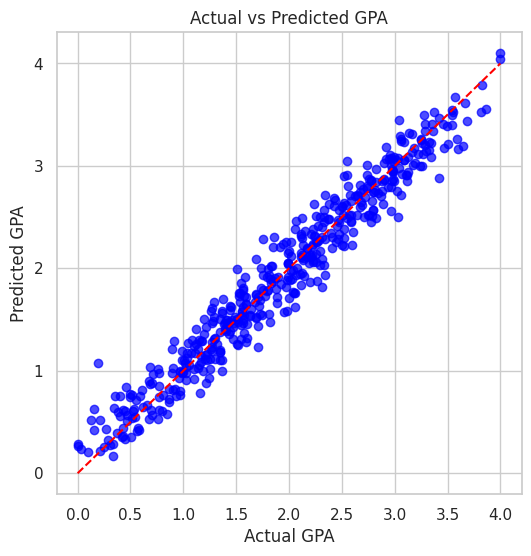

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(results['Actual GPA'], results['Predicted GPA'], color='blue', alpha=0.7)

plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Actual vs Predicted GPA')

plt.plot([results['Actual GPA'].min(), results['Actual GPA'].max()],
         [results['Actual GPA'].min(), results['Actual GPA'].max()],
         color='red', linestyle='--')

plt.show()

**From the Scatter Plot (Actual vs Predicted GPA)**
1. **Strong Model Fit (High Accuracy)**
  * Most points lie **very close to the diagonal line
  * Confirms the earlier results **R² ≈ 0.95**

Means, the model is highly accurate in predicting GPA across most students.


2. **Linear Pattern is Very Clear**
  * GPA is strongly driven by **linear relationships**, not complex patterns.
  
  This why **Linear Regression outperformed Random Forest**


3. **Small but Visible Errors (Important)**
  * Some points slightly above/below the line
  * Errors are **not random**, but small deviations

**Insights** the model performs conssistently, but there are minor prediction gaps that may reflect unobserved factors (e.g., motivation, learning style).

**4. No Extreme Outliers**
  * We see there is no points far away from the line, which indicates this dataset is clean and well-behaved, with no abnormal student patterns.


### **4.6 Residual Analysis**
The purpose of this helps to check:
* whether prediction errors are randomly spread
* whether the model is systematically overpredicting or underpredicting
* whether Linear regression is still a reasonable choice.

In [46]:
results['Residual'] = results['Actual GPA'] - results['Predicted GPA']


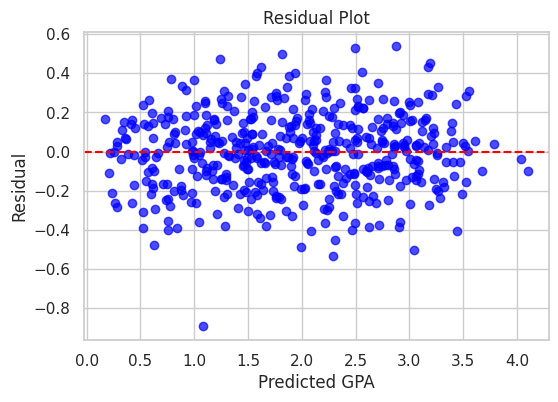

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(results['Predicted GPA'], results['Residual'], color='blue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted GPA')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

**INSIGHTS**

**1. Random Spread Around Zero = GOOD** : the model is not systematically biased (no consistent over/under prediction)

**2. No Clear Pattern = Linear Model is Valid**: this confirms earlier result of Linear > Random Forest.

**3. Slight Outliers Exist (Normal)**. Means, some students behave differently from the general pattern

**FINAL MODEL SELECTION** is linear regression.

In [48]:
# save to joblib just in case we want to deploy streamlit
joblib.dump(model, 'gpa_model.pkl')

['gpa_model.pkl']

and we want to check if the categorical variables already numeric or not. because it not, we must handle it first.

In [49]:
X.dtypes

,0
Age,int64
Gender,int64
Ethnicity,int64
ParentalEducation,int64
StudyTimeWeekly,float64
Absences,int64
Tutoring,int64
ParentalSupport,int64
Extracurricular,int64
Sports,int64


and its all already in numeric. but we are going a build pipeline so future decreasing the risk of the not mathcing of future data and pipeline ensures consistency.

In [50]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# train pipeline
pipeline.fit(X_train, y_train)

# test again (optional)
y_pred_pipe = pipeline.predict(X_test)
print("Pipeline R2:", r2_score(y_test, y_pred_pipe))

Pipeline R2: 0.9532471681022928


In [51]:
# save pipeline
joblib.dump(pipeline, 'gpa_pipeline.pkl')

['gpa_pipeline.pkl']

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred_pipe = pipeline.predict(X_test)

mse_pipe = mean_squared_error(y_test, y_pred_pipe)
r2_pipe = r2_score(y_test, y_pred_pipe)

print("Pipeline MSE:", mse_pipe)
print("Pipeline R2:", r2_pipe)

Pipeline MSE: 0.03866144149454257
Pipeline R2: 0.9532471681022928


and now we are going to save deployment artifacts.

In [53]:
# 1save pipeline
joblib.dump(pipeline, 'gpa_pipeline.pkl')

# savee feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

# save coefficients (for explanation later)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': pipeline.named_steps['model'].coef_
})

joblib.dump(coef_df, 'coef_df.pkl')

['coef_df.pkl']

## **5. Ensamble Modeling (Random Forest)**

### 5. Ensemble Model (Random Forest)

In this step, we build an ensemble model using Random Forest to improve prediction performance and stability compared to the baseline Linear Regression model.

Unlike Linear Regression, which assumes a linear relationship between features and the target variable (GPA), Random Forest is a tree-based ensemble method that can capture more complex and non-linear relationships in the data.

The purpose of this step is to:
- Evaluate whether a more complex model can improve prediction accuracy
- Compare performance with the baseline model
- Prepare a model that will later be optimized using hyperparameter tuning (Optuna)

Random Forest works by combining multiple decision trees, where each tree learns different patterns from the data. The final prediction is obtained by averaging the predictions from all trees, which helps reduce overfitting and improve generalization.

This model will serve as the foundation for further optimization in the next step.

In [54]:
rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])


In [55]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf_pipe = rf_pipeline.predict(X_test)


In [56]:
mse_rf_pipe = mean_squared_error(y_test, y_pred_rf_pipe)
r2_rf_pipe = r2_score(y_test, y_pred_rf_pipe)


In [57]:
print("RF Pipeline MSE:", mse_rf_pipe)
print("RF Pipeline R2:", r2_rf_pipe)

RF Pipeline MSE: 0.06049515597539183
RF Pipeline R2: 0.9268439109198162


#### **Comparison: Linear Regression vs Random Forest**

The performance of the Random Forest model is compared with the baseline Linear Regression model:

| Model               | MSE     | R²     |
|---------------------|---------|--------|
| **Linear Regression**   | 0.0386  | 0.9532 |
| **Random Forest**       | 0.0605  | 0.9268 |

From the results, Linear Regression outperforms Random Forest in both MSE and R².

This indicates that the relationship between features and GPA is largely linear, and a simple model is sufficient to capture the underlying patterns in the data.

Although Random Forest is capable of modeling complex and non-linear relationships, it does not provide additional performance benefits in this case and may introduce unnecessary complexity.

However, Random Forest will still be used in the next step for hyperparameter tuning using Optuna, as required by the assignment and to explore whether performance can be improved further.

## **6. Hyperparameter Tuning with Optuna**


In this step, we use Optuna to optimize the hyperparameters of the Random Forest model.

Hyperparameter tuning is important because the default parameters of a model are not always optimal. By searching for the best combination of parameters, we can improve model performance and generalization.

Optuna is an automated hyperparameter optimization framework that efficiently explores the parameter space to find the best configuration based on a defined objective function.

In [67]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
!pip install optuna

In [64]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
    }

    model = RandomForestRegressor(**params, random_state=42)

    score = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring='neg_mean_squared_error'
    ).mean()

    return score

In [65]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)

[I 2026-04-06 04:59:20,924] A new study created in memory with name: no-name-b0b9c6d8-78b7-42c9-b802-17991871b2cb
[I 2026-04-06 04:59:22,032] Trial 0 finished with value: -0.06621405688738256 and parameters: {'n_estimators': 129, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: -0.06621405688738256.
[I 2026-04-06 04:59:23,244] Trial 1 finished with value: -0.06512487201516635 and parameters: {'n_estimators': 80, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 1 with value: -0.06512487201516635.
[I 2026-04-06 04:59:25,731] Trial 2 finished with value: -0.06469420593886387 and parameters: {'n_estimators': 124, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 2 with value: -0.06469420593886387.
[I 2026-04-06 04:59:29,117] Trial 3 finished with value: -0.06590539845820576 and parameters: {'n_estimators': 199, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 2

Best Parameters: {'n_estimators': 187, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 1}


For note,
* We use **cross-validation** to make it more reliable
* We optimize **MSe (negative)** for better generalization

In [68]:
best_params = study.best_params

tuned_rf = RandomForestRegressor(**best_params, random_state=42)
tuned_rf.fit(X_train, y_train)

y_pred_tuned = tuned_rf.predict(X_test)



In [70]:
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned RF MSE:", mse_tuned)
print("Tuned RF R2:", r2_tuned)

Tuned RF MSE: 0.05909343633424047
Tuned RF R2: 0.9285389941918591


## **7. Model Comparison and Evaluation**

The performance of all models is summarized below:

| Model                  | MSE     | R²     |
|------------------------|---------|--------|
| **Linear Regression**      | 0.0386  | 0.9532 |
| **Random Forest (Default)**| 0.0605  | 0.9268 |
| **Random Forest (Tuned)**  | 0.0591  | 0.9285 |

Hyperparameter tuning using Optuna slightly improved the performance of the Random Forest model. However, the improvement was not significant, and the model still did not outperform Linear Regression.

This suggests that the dataset has a strong linear relationship between features and GPA, making Linear Regression a more suitable and efficient model.

Therefore, Linear Regression is selected as the final model due to its superior performance and simplicity.

Now we are going to do **Distribution Comparison**. Here we are going to compare:
* Actual GPA distribution
* Predicted GPA distribution

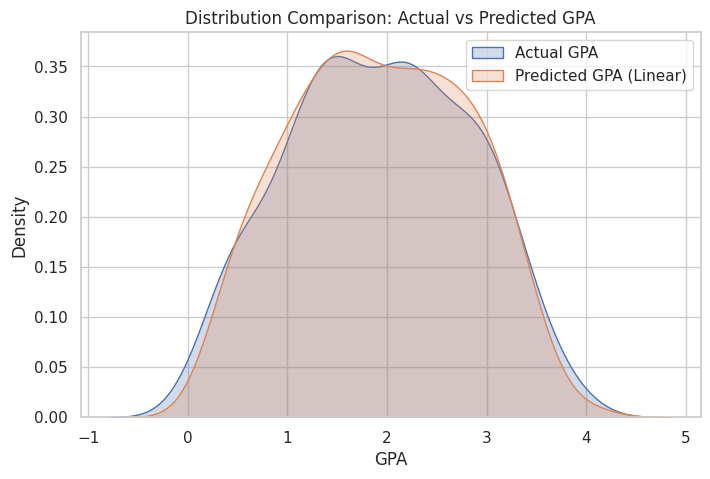

In [71]:
plt.figure(figsize=(8,5))

sns.kdeplot(y_test, label='Actual GPA', fill=True)
sns.kdeplot(y_pred, label='Predicted GPA (Linear)', fill=True)

plt.title('Distribution Comparison: Actual vs Predicted GPA')
plt.legend()
plt.show()

**Distribution Comparison: Actual vs Predicted GPA**

* The predicted GPA distribution closely matches the actual distribution, indicating that the model effectively captures the overall pattern of the data.

* There are minor differences, but no clear signs of systematic overestimation or underestimation.

* This confirms that the Linear Regression model performs well not only in metrics (R² and MSE) but also in representing the data distribution.

## 7. **CONFUSION MATRIX**

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [73]:
def categorize_gpa(gpa):
    if gpa < 2:
        return 'Low'
    elif gpa < 3:
        return 'Medium'
    else:
        return 'High'

y_test_cat = y_test.apply(categorize_gpa)
y_pred_cat = pd.Series(y_pred).apply(categorize_gpa)


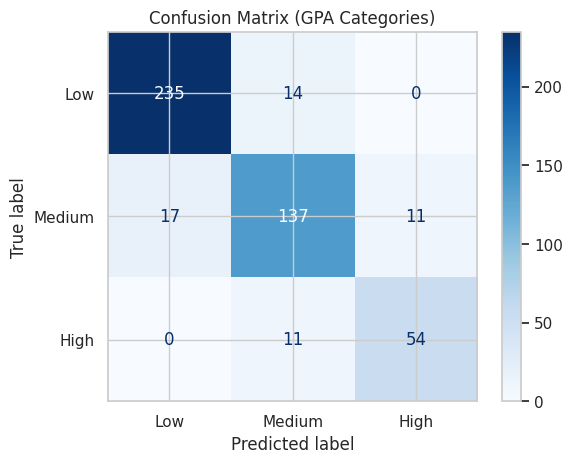

In [74]:
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=['Low','Medium','High'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','Medium','High'])
disp.plot(cmap='Blues')

plt.title('Confusion Matrix (GPA Categories)')
plt.show()

#### **Confusion Matrix Interpretation (GPA Categories)**

The model demonstrates strong performance in correctly identifying student performance levels across all categories.

Most students in the **Low GPA category (235)** are correctly classified, indicating that the model is highly effective at detecting students who are at academic risk. This is particularly valuable from a business or institutional perspective, as early identification enables timely intervention programs.

For the **Medium category**, the model also performs well (137 correct predictions), although there are some misclassifications into both Low and High. This suggests that students in this group are more ambiguous and may fluctuate in performance, making them important targets for monitoring and support.

In the **High GPA category**, the majority of students (54) are correctly identified, with only a small number misclassified as Medium. This indicates that high-performing students are generally well recognized by the model.

Importantly, most errors occur between **adjacent categories (Low ↔ Medium, Medium ↔ High)** rather than extreme misclassifications. This means the model rarely makes critical mistakes, such as predicting a Low-performing student as High-performing.

From a business perspective, this behavior is desirable because:
- It ensures reliable identification of at-risk students (Low category)
- It minimizes high-risk misclassification errors
- It supports targeted intervention strategies based on student performance levels

Overall, the model is suitable for practical use in educational decision-making, particularly for identifying students who require additional academic support.

### **Reflection & Key Learnings**

Working with both Linear Regression and Random Forest in this project highlighted an important lesson: model complexity does not always translate into better performance.

Ensemble methods like Random Forest are generally more stable because they combine multiple models (decision trees), each capturing different patterns in the data. This reduces variance and helps avoid overfitting compared to relying on a single model. In many real-world scenarios, this makes ensemble approaches more robust and reliable.

However, in this case study, the results showed that Random Forest — even after tuning — did not outperform Linear Regression. This suggests that the underlying relationship between features and GPA is largely linear and well-structured. As a result, a simpler model was already sufficient to capture the key patterns, and adding complexity did not bring significant improvement. This experience reinforced the idea that choosing the right model should always be driven by the nature of the data, not just by model sophistication.

Another key learning came from the hyperparameter tuning process using Optuna. During experimentation, it became clear that parameters such as the number of trees (n_estimators), maximum depth (max_depth), and minimum samples per split significantly influence how the model learns. Small changes in these parameters could slightly improve performance, indicating that the model is sensitive to how complexity and generalization are balanced.

That said, the improvements from tuning were relatively modest. This highlighted an important insight: hyperparameter tuning can optimize a model, but it cannot fundamentally change the nature of the data. If the data follows a simple structure, even a well-tuned complex model may not outperform a simpler approach.

Overall, this project emphasized the importance of:
- understanding the data before choosing the model,
- validating assumptions through comparison,
- and using tuning as a refinement step rather than a guaranteed solution for performance improvement.

In [75]:
# more for streamlit if later want to build it.

# 1. save GPA category

gpa_bins = {
    'low': 2,
    'medium': 3
}

joblib.dump(gpa_bins, 'gpa_bins.pkl')

['gpa_bins.pkl']

In [76]:
# 2. save feature importance direction
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)
joblib.dump(coef_df_sorted, 'coef_sorted.pkl')

['coef_sorted.pkl']

In [78]:
import os

os.listdir()

['.config',
 'gpa_bins.pkl',
 'feature_names.pkl',
 'columns_config.json',
 'gpa_model.pkl',
 'StudentPerformance.csv',
 'coef_df.pkl',
 'gpa_pipeline.pkl',
 'coef_sorted.pkl',
 'sample_data']

In [80]:
pipeline = joblib.load('gpa_pipeline.pkl')
feature_names = joblib.load('feature_names.pkl')
coef_df = joblib.load('coef_df.pkl')

In [81]:
try:
    gpa_bins = joblib.load('gpa_bins.pkl')
    print("gpa_bins:", gpa_bins)
except:
    print("gpa_bins not found")

print("Pipeline loaded:", pipeline)
print("Feature names:", feature_names[:5])
print("Coef preview:")
print(coef_df.head())

gpa_bins: {'low': 2, 'medium': 3}
Pipeline loaded: Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])
Feature names: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly']
Coef preview:
             Feature  Coefficient
0                Age    -0.006448
1             Gender     0.005256
2          Ethnicity     0.004895
3  ParentalEducation     0.000124
4    StudyTimeWeekly     0.165558


In [82]:
# create dummy input (match feature order)
sample = pd.DataFrame([{
    'Age': 18,
    'Gender': 1,
    'Ethnicity': 0,
    'ParentalEducation': 2,
    'StudyTimeWeekly': 10,
    'Absences': 5,
    'Tutoring': 1,
    'ParentalSupport': 2,
    'Extracurricular': 1,
    'Sports': 0,
    'Music': 0,
    'Volunteering': 1
}])

prediction = pipeline.predict(sample)
print("Sample Prediction:", prediction)

Sample Prediction: [3.04367299]
